# Rain Prediction (Australia) — Exploratory Data Analysis

Predict whether it rains the next day at a given Australian weather station using daily measurements (temperature, humidity, wind, pressure) from the Kaggle weatherAUS dataset (~145,000 rows across 49 stations, 2007-2017).

**Target:** `RainTomorrow` (0 = No Rain, 1 = Rain)

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = pd.read_csv('data/weatherAUS.csv')
# Reload via utils.load_data to drop high-NaN columns, drop rows with NaN target, etc.
from utils import load_data
df = load_data()
print('Shape:', df.shape)
df.head()

Shape: (142193, 20)


,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month,Year
0,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,0,0,12,2008
1,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,0,0,12,2008
2,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,0,0,12,2008
3,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,0,0,12,2008
4,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,0,0,12,2008


## 2. Dataset Overview

In [3]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes.value_counts())

Shape: (142193, 20)

Dtypes:
float64    12
object      4
int64       2
int32       2
Name: count, dtype: int64


In [4]:
df.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Location,142193,49,Canberra,3418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MinTemp,141556.0,NaN,NaN,NaN,12.1864,6.403283,-8.5,7.6,12.0,16.8,33.9
MaxTemp,141871.0,NaN,NaN,NaN,23.226784,7.117618,-4.8,17.9,22.6,28.2,48.1
Rainfall,140787.0,NaN,NaN,NaN,2.349974,8.465173,0.0,0.0,0.0,0.8,371.0
WindGustDir,132863,16,W,9780,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WindGustSpeed,132923.0,NaN,NaN,NaN,39.984292,13.588801,6.0,31.0,39.0,48.0,135.0
WindDir9am,132180,16,N,11393,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WindDir3pm,138415,16,SE,10663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WindSpeed9am,140845.0,NaN,NaN,NaN,14.001988,8.893337,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,139563.0,NaN,NaN,NaN,18.637576,8.803345,0.0,13.0,19.0,24.0,87.0


In [5]:
print('Duplicate rows:', df.duplicated().sum())
print('Memory (MB):', round(df.memory_usage(deep=True).sum() / 1024**2, 2))

Duplicate rows: 28
Memory (MB): 44.5


## 3. Missing / Invalid Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_df):
    print(missing_df)
else:
    print('No explicit NaN values')

               Missing  Percent
Pressure9am      14014     9.86
Pressure3pm      13981     9.83
WindDir9am       10013     7.04
WindGustDir       9330     6.56
WindGustSpeed     9270     6.52
WindDir3pm        3778     2.66
Humidity3pm       3610     2.54
Temp3pm           2726     1.92
WindSpeed3pm      2630     1.85
Humidity9am       1774     1.25
Rainfall          1406     0.99
WindSpeed9am      1348     0.95
Temp9am            904     0.64
MinTemp            637     0.45
MaxTemp            322     0.23


## 4. Target Variable Distribution

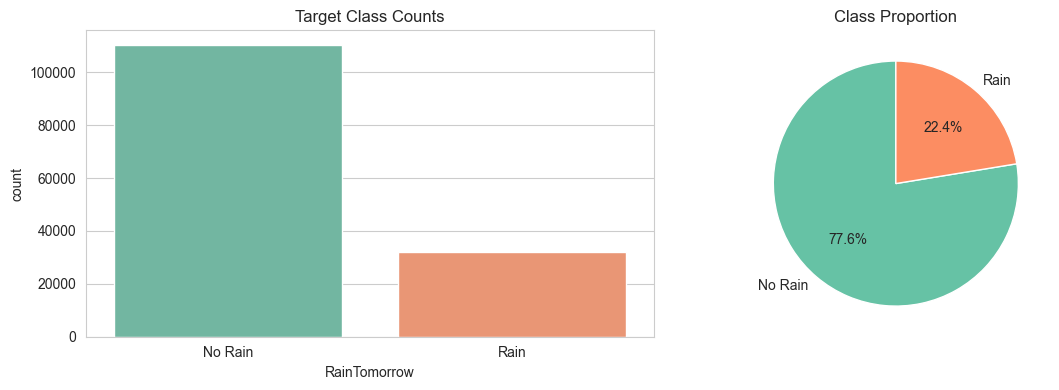


Class balance (%):
RainTomorrow
0    77.58
1    22.42
Name: count, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
target_counts = df['RainTomorrow'].value_counts().sort_index()
sns.countplot(x='RainTomorrow', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Target Class Counts')
axes[0].set_xticklabels(['No Rain', 'Rain'])
axes[1].pie(target_counts, labels=['No Rain', 'Rain'], autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Class Proportion')
plt.tight_layout(); plt.show()
print('\nClass balance (%):')
print((target_counts / target_counts.sum() * 100).round(2))

## 5. Univariate Analysis — Numeric Features

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'RainTomorrow' in numeric_cols:
    numeric_cols.remove('RainTomorrow')
print(f'Numeric features ({len(numeric_cols)}):')
print(numeric_cols)

Numeric features (15):
['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'Month', 'Year']


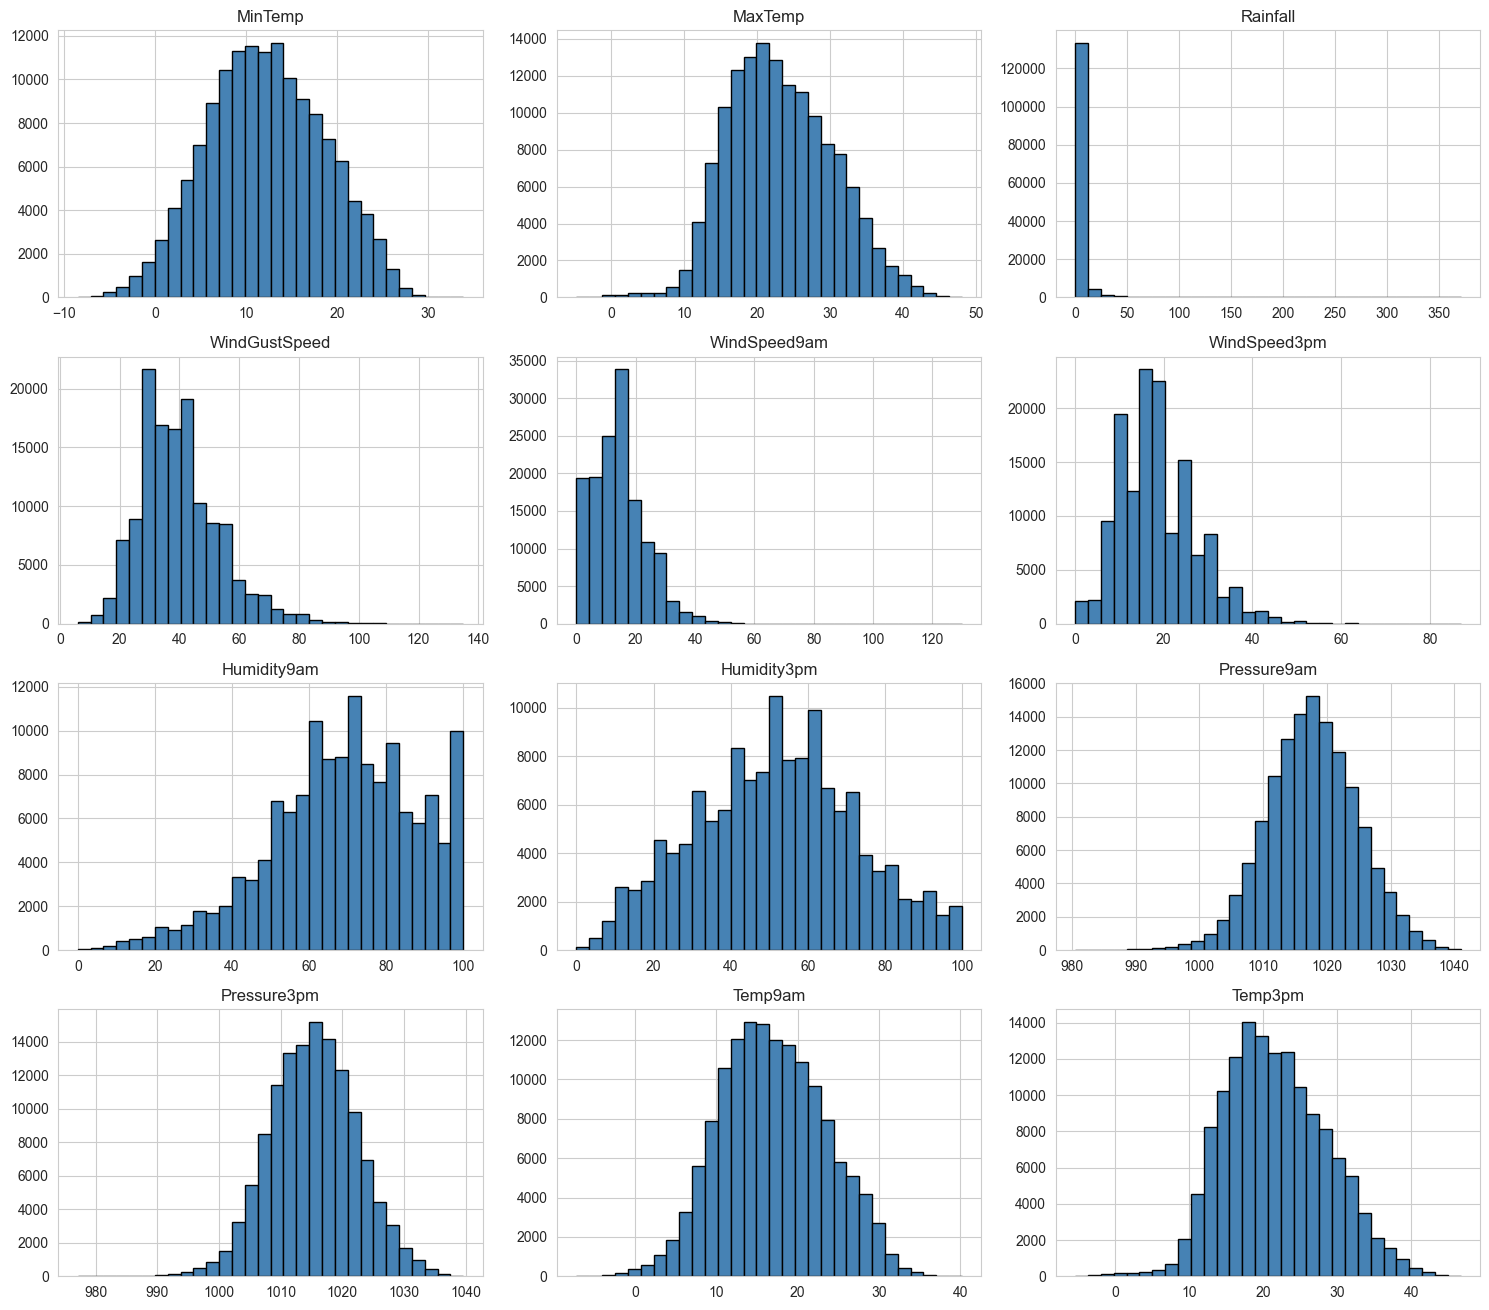

In [9]:
import math
n_show = min(len(numeric_cols), 12)
ncols = 3
nrows = math.ceil(n_show / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

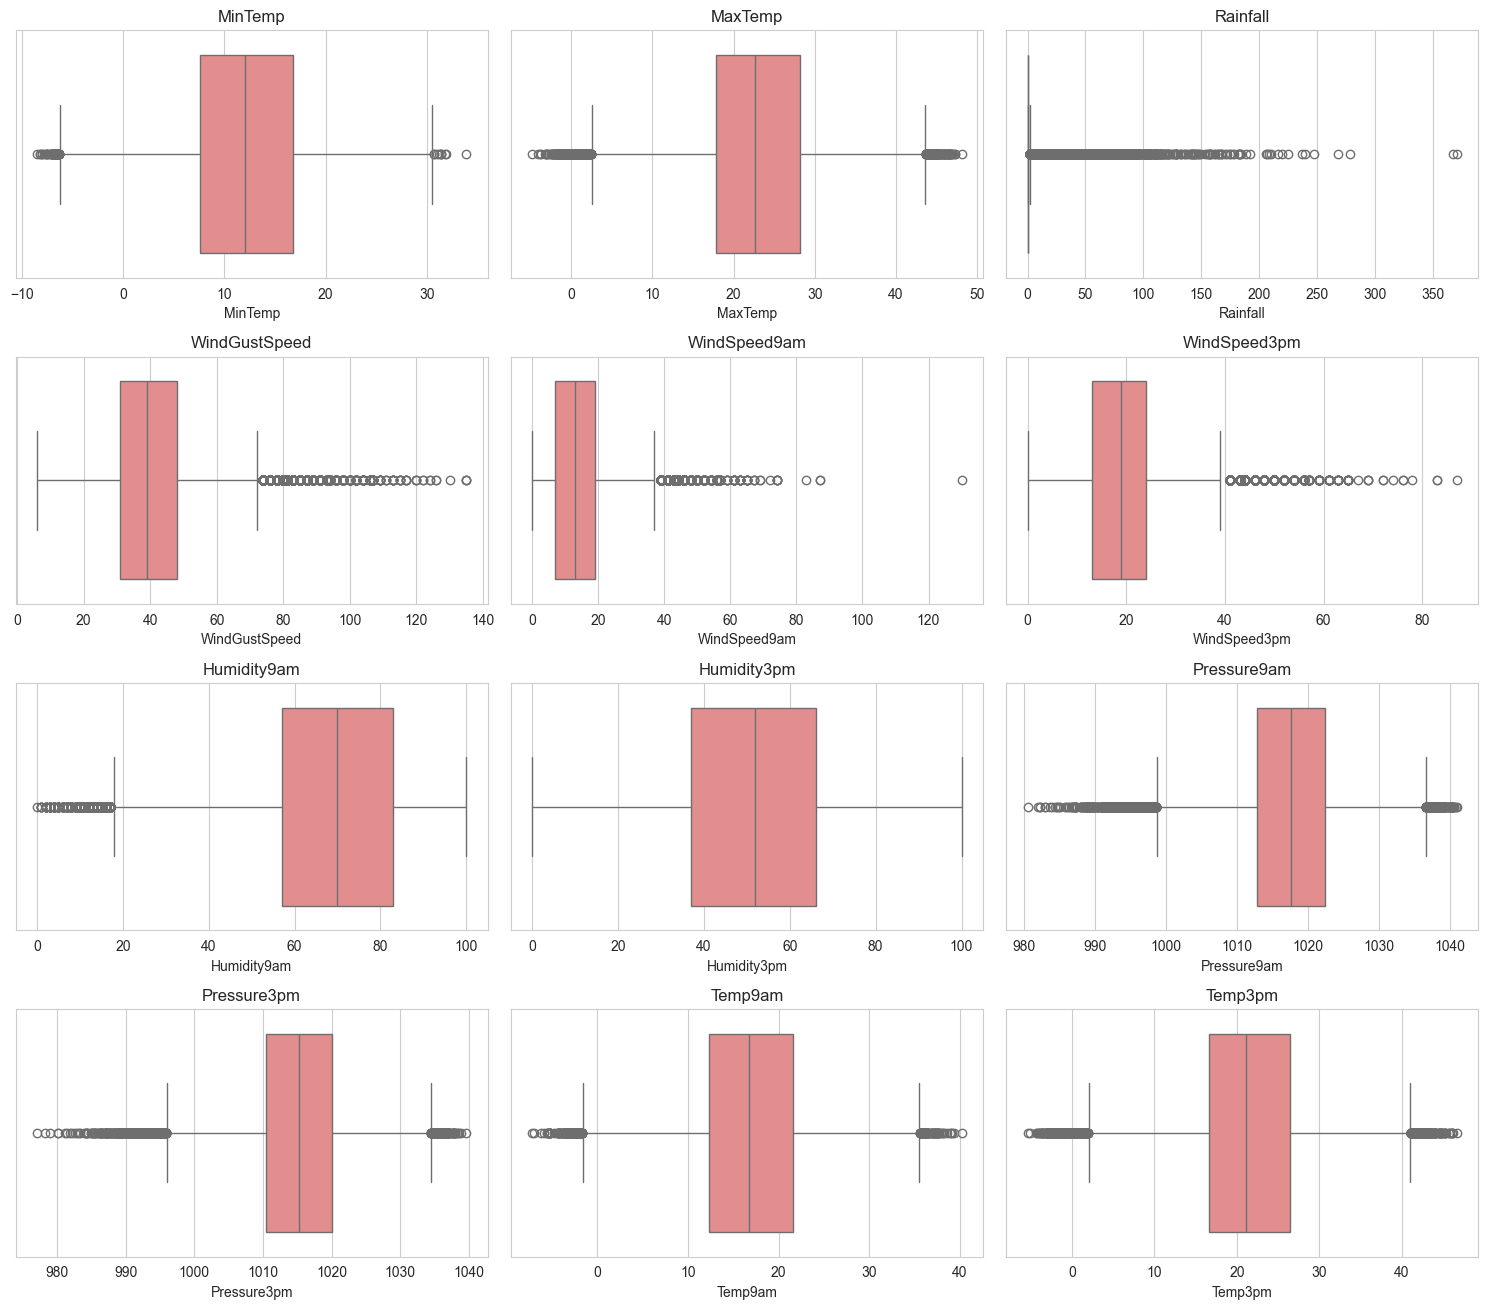

In [10]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3*nrows))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(numeric_cols[:n_show]):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)
for j in range(n_show, len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

## 6. Bivariate Analysis — Features vs Target

In [11]:
corrs_all = df[numeric_cols + ['RainTomorrow']].corr()['RainTomorrow'].abs().sort_values(ascending=False)
top_features = [c for c in corrs_all.index if c != 'RainTomorrow'][:6]
print('Top features by |correlation| with target:')
print(corrs_all[top_features].round(3))

Top features by |correlation| with target:
Humidity3pm      0.446
RainToday        0.307
Humidity9am      0.257
Pressure9am      0.246
Rainfall         0.239
WindGustSpeed    0.234
Name: RainTomorrow, dtype: float64


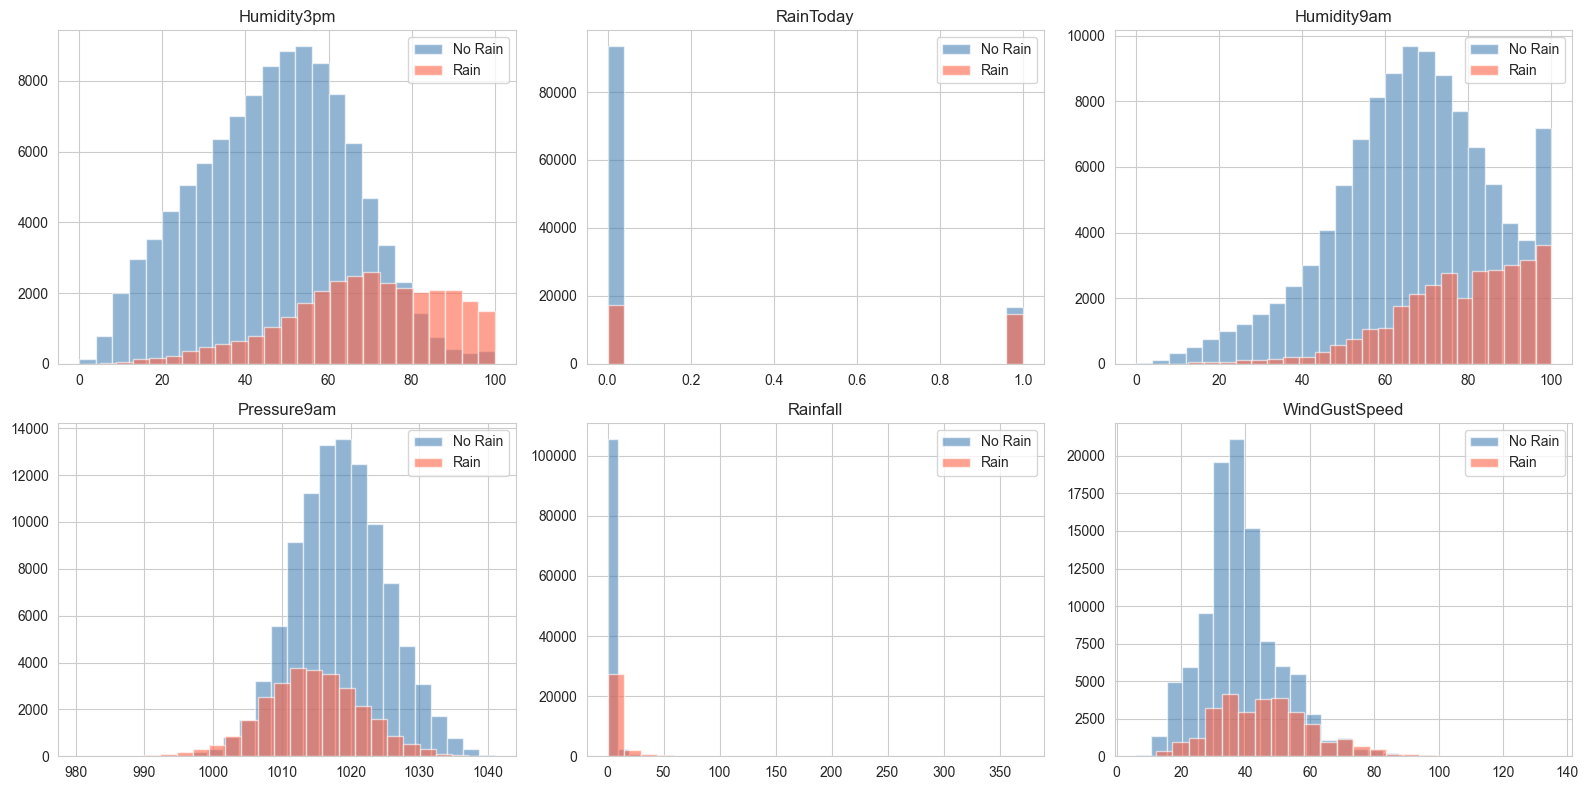

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
labels = ['No Rain', 'Rain']
colors = ['steelblue', 'tomato']
for i, col in enumerate(top_features[:6]):
    for cls, lbl, c in [(0, labels[0], colors[0]), (1, labels[1], colors[1])]:
        axes[i].hist(df[df['RainTomorrow']==cls][col].dropna(), bins=25, alpha=0.6, label=lbl, color=c)
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

In [13]:
means = df.groupby('RainTomorrow')[numeric_cols].mean().T
means.columns = ['No Rain', 'Rain']
means['Difference'] = means.iloc[:, 1] - means.iloc[:, 0]
means.sort_values('Difference', key=abs, ascending=False).round(3).head(15)

,No Rain,Rain,Difference
Humidity3pm,46.511,68.800,22.289
Humidity9am,66.218,77.983,11.766
WindGustSpeed,38.288,45.947,7.658
Rainfall,1.270,6.142,4.872
Pressure9am,1018.596,1014.400,-4.196
Pressure3pm,1016.114,1012.301,-3.813
Temp3pm,22.403,19.197,-3.206
MaxTemp,23.836,21.119,-2.717
WindSpeed9am,13.567,15.509,1.941
WindSpeed3pm,18.223,20.079,1.856


## 7. Correlation Analysis

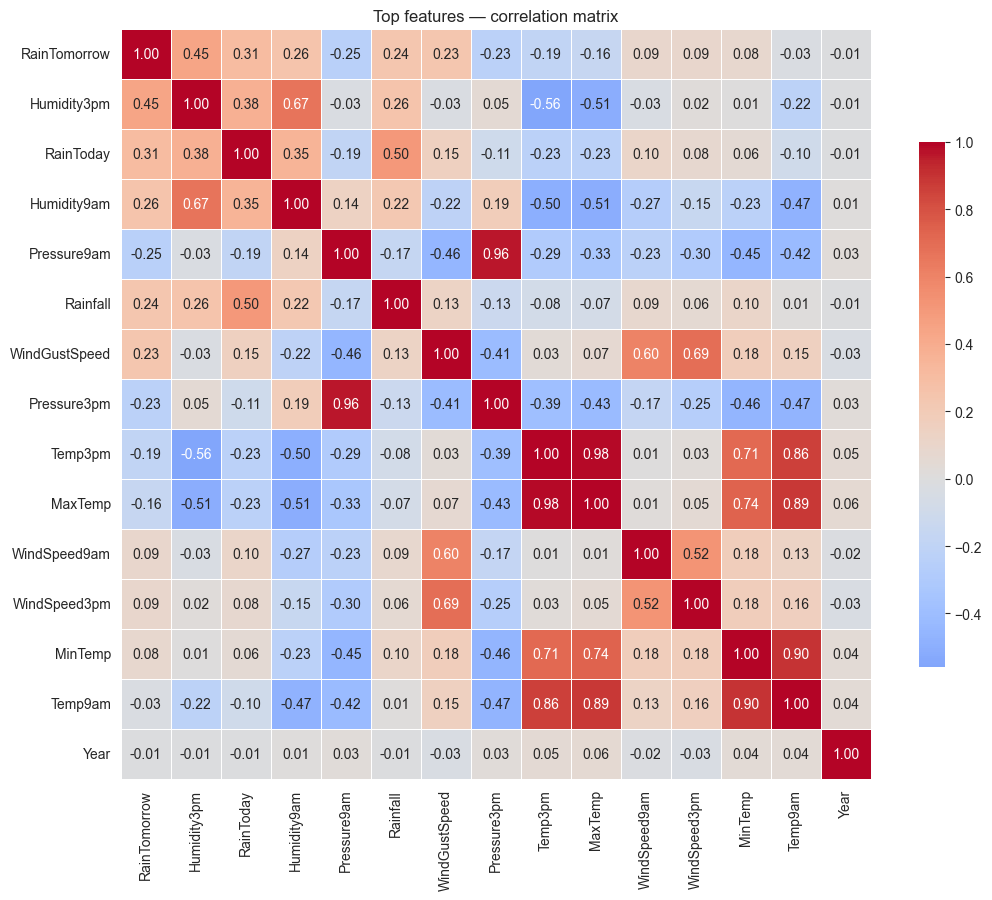

In [14]:
# Restrict to top numeric features for legibility
top_numeric = corrs_all.head(15).index.tolist()
if 'RainTomorrow' not in top_numeric:
    top_numeric.append('RainTomorrow')
corr_matrix = df[top_numeric].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Top features — correlation matrix'); plt.tight_layout(); plt.show()

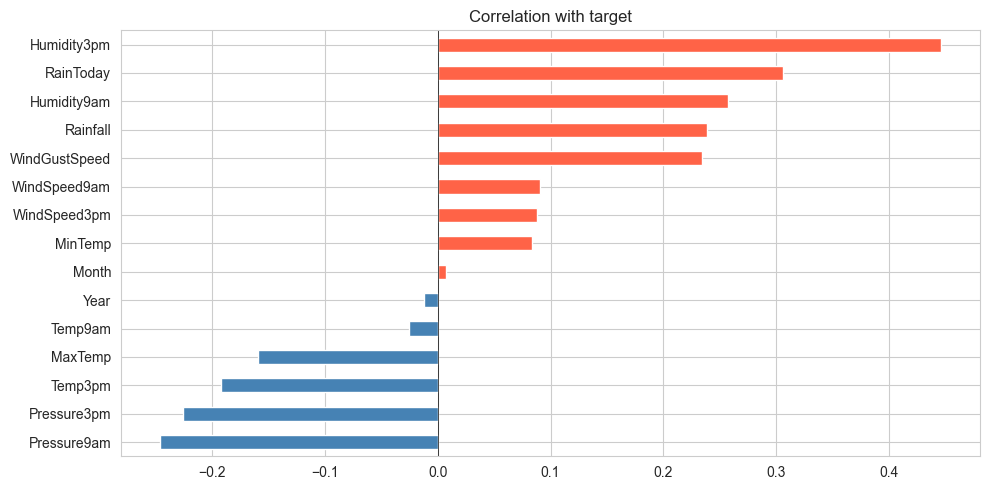

In [15]:
target_corr = df[numeric_cols + ['RainTomorrow']].corr()['RainTomorrow'].drop('RainTomorrow').sort_values()
plt.figure(figsize=(10, max(5, len(target_corr)*0.25)))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Correlation with target')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout(); plt.show()

## 8. Domain Deep-Dive — Geography, Season, and Weather Drivers

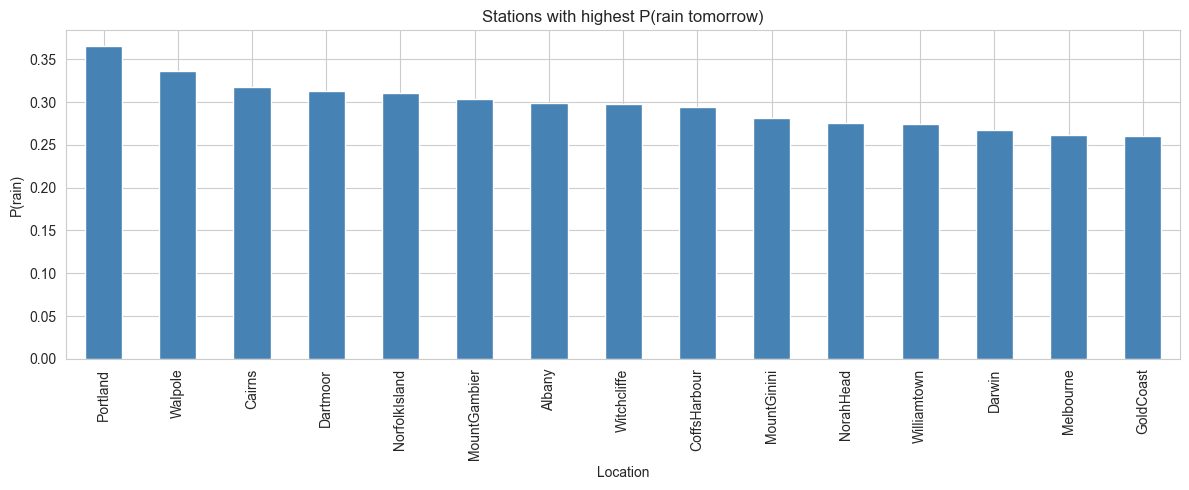

In [16]:
# Top 10 stations by rain-tomorrow rate
by_loc = df.groupby('Location')['RainTomorrow'].agg(['mean', 'count'])
by_loc = by_loc[by_loc['count'] > 200].sort_values('mean', ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
by_loc['mean'].head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Stations with highest P(rain tomorrow)'); ax.set_ylabel('P(rain)')
plt.tight_layout(); plt.show()

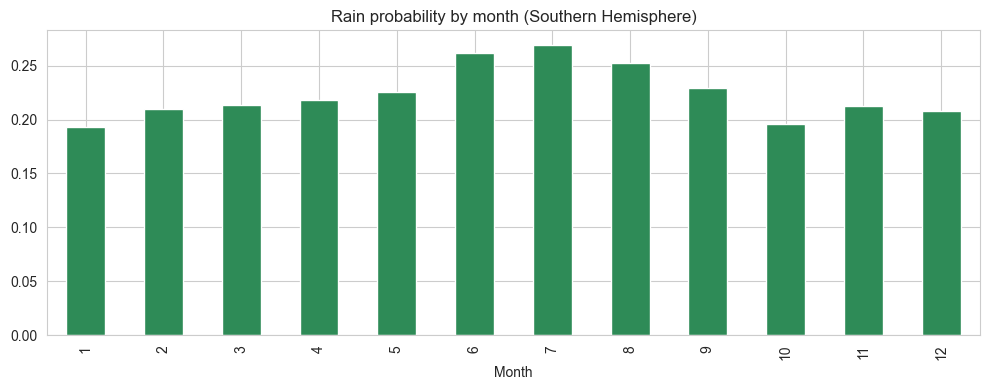

In [17]:
# Rain rate by month
if 'Month' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    df.groupby('Month')['RainTomorrow'].mean().plot(kind='bar', ax=ax, color='seagreen')
    ax.set_title('Rain probability by month (Southern Hemisphere)')
    plt.tight_layout(); plt.show()

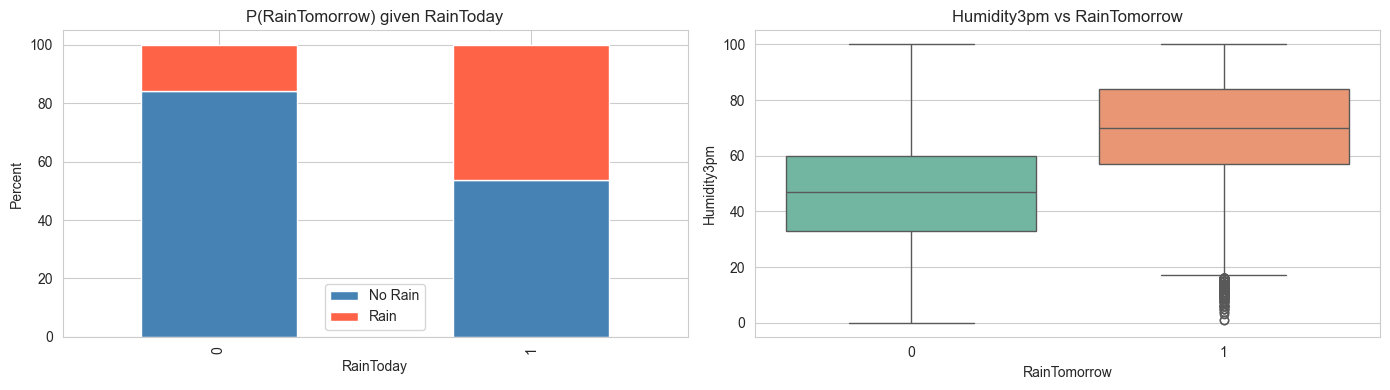

In [18]:
# RainToday is a strong leading indicator
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ct = pd.crosstab(df['RainToday'], df['RainTomorrow'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('P(RainTomorrow) given RainToday')
axes[0].set_ylabel('Percent'); axes[0].legend(['No Rain', 'Rain'])
sns.boxplot(x='RainTomorrow', y='Humidity3pm', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Humidity3pm vs RainTomorrow')
plt.tight_layout(); plt.show()

## 9. Pair Plot of Top Features

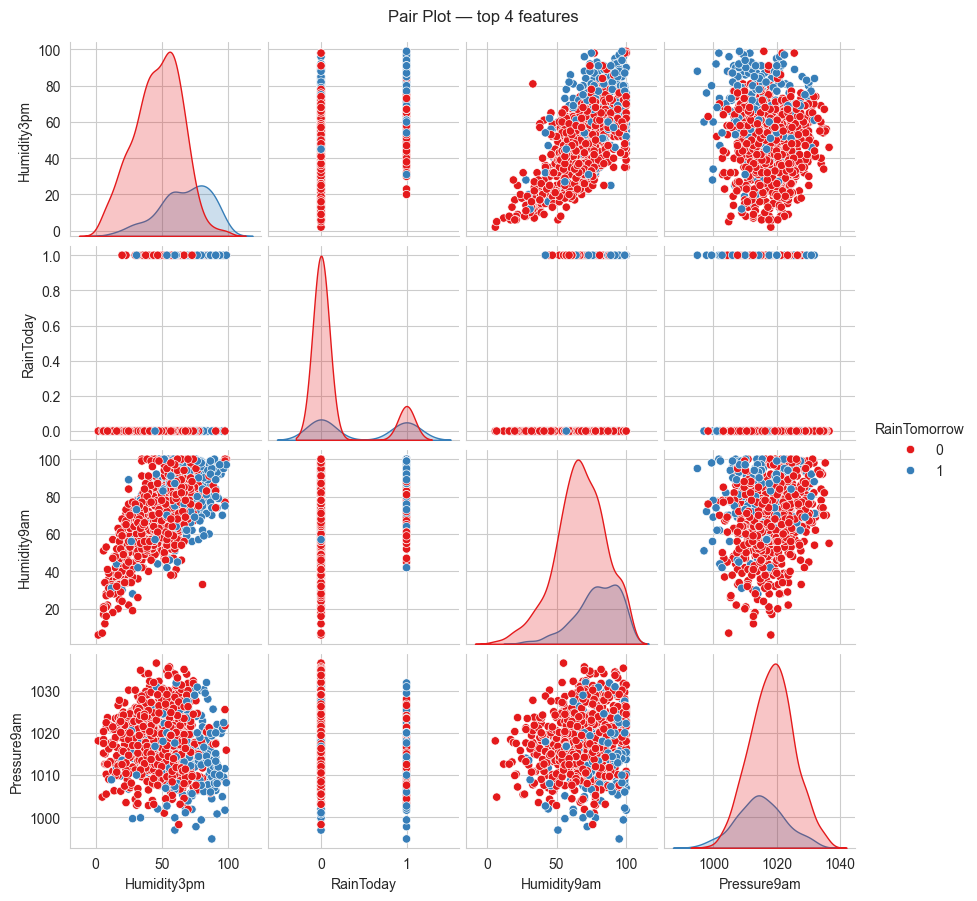

In [19]:
sample = df.sample(min(1000, len(df)), random_state=42)
sns.pairplot(sample[top_features[:4] + ['RainTomorrow']].dropna(),
             hue='RainTomorrow', palette='Set1', diag_kind='kde', height=2.2)
plt.suptitle('Pair Plot — top 4 features', y=1.02); plt.show()

## 10. Summary of Key Findings

In [20]:
summary = pd.DataFrame({
    'Metric': ['Total samples', 'Total features', 'Class 0 count', 'Class 1 count',
               'Class imbalance ratio', 'Top correlated feature', 'Top correlation value'],
    'Value': [
        len(df),
        df.shape[1] - 1,
        int((df['RainTomorrow'] == 0).sum()),
        int((df['RainTomorrow'] == 1).sum()),
        f"{(df['RainTomorrow'] == 0).sum() / max(1, (df['RainTomorrow'] == 1).sum()):.2f}:1",
        top_features[0],
        round(corrs_all[top_features[0]], 3),
    ],
})
summary

,Metric,Value
0,Total samples,142193
1,Total features,19
2,Class 0 count,110316
3,Class 1 count,31877
4,Class imbalance ratio,3.46:1
5,Top correlated feature,Humidity3pm
6,Top correlation value,0.446
